#### NALAR FINAL PROJECT 
#### Klasifikasi Objek Langit Berdasarkan Data Fotometri SDSS Menggunakan Machine Learning
---
 Author     : Wa Ode Nisrina Sayyidah Hidayat                 
 Date       : 2026

In [1]:
# ── Import Library ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import joblib

 #── Plot Style ─────────────────────────────────────────────────────────────────
plt.rcParams["figure.dpi"]      = 130
plt.rcParams["font.family"]     = "DejaVu Sans"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
PALETTE = "#2C3E50"

ImportError: cannot import name set_module

#### 1. Data Understanding

In [2]:
# Load dataset 
# Download raw path dataset at : https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17
RAW_PATH = "star_classification.csv"   
df = pd.read_csv(RAW_PATH)

print("\nUkuran dan Kolom Dataset")
print("-" * 60)
print("\nDataset shape      :", df.shape)
print("\nColumns            :", df.columns)

NameError: name 'pd' is not defined

Untuk menghindari data leakage dan sesuai tujuan proyek ini yaitu klasifikasi hanya berdasarkan fitur numerik fotometri u, g, r, i, z maka dibentuklah subset berisi kelima variabel fotometrik dan class target.

In [53]:
# Variabel untuk di buang
dropped = ['obj_ID', 'alpha', 'delta', 'run_ID', 'rerun_ID', 
       'cam_col', 'field_ID', 'spec_obj_ID', 'redshift',
       'plate', 'MJD', 'fiber_ID']

# Pengambilan subset data
df = df.drop(columns=dropped)

print("\nUkuran dan Kolom Dataset Baru")
print("-" * 60)
print("\nDataset shape      :", df.shape)
print("\nColumns            :", df.columns)


Ukuran dan Kolom Dataset Baru
------------------------------------------------------------

Dataset shape      : (100000, 6)

Columns            : Index(['u', 'g', 'r', 'i', 'z', 'class'], dtype='str')


In [28]:
# Statistik deskriptif 
df.describe()

,u,g,r,i,z
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,21.980468,20.531387,19.645762,19.084854,18.668810
std,31.769291,31.750292,1.854760,1.757895,31.728152
min,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000
25%,20.352353,18.965230,18.135828,17.732285,17.460677
50%,22.179135,21.099835,20.125290,19.405145,19.004595
75%,23.687440,22.123767,21.044785,20.396495,19.921120
max,32.781390,31.602240,29.571860,32.141470,29.383740


Dari statistika deskriptif tersebut ditemukan adanya outlier di variabel u, g, z berupa nilai minimum -999 yang kemungkinan adalah anomali. Untuk penanganannya adalah dengan menghapus nilai anomali dengan nilai dibawah 0.

In [54]:
mag_columns = ['u', 'g', 'r', 'i', 'z']
df[mag_columns] = df[mag_columns].mask(df[mag_columns] < 0, np.nan)

# Evaluasi kerusakan
missing_percentage = (df[mag_columns].isnull().sum() / len(df)) * 100
print("Persentase Data Hilang per Kolom (%) setelah sapu bersih:")
print(missing_percentage)

Persentase Data Hilang per Kolom (%) setelah sapu bersih:
u    0.001
g    0.001
r    0.000
i    0.000
z    0.001
dtype: float64


In [ ]:
# Hapus nilai nan/anomali
df = df.dropna()

,u,g,r,i,z,class
0,23.87882,22.27530,20.39501,19.16573,18.79371,GALAXY
1,24.77759,22.83188,22.58444,21.16812,21.61427,GALAXY
2,25.26307,22.66389,20.60976,19.34857,18.94827,GALAXY
3,22.13682,23.77656,21.61162,20.50454,19.25010,GALAXY
4,19.43718,17.58028,16.49747,15.97711,15.54461,GALAXY
...,...,...,...,...,...,...
99995,22.16759,22.97586,21.90404,21.30548,20.73569,GALAXY
99996,22.69118,22.38628,20.45003,19.75759,19.41526,GALAXY
99997,21.16916,19.26997,18.20428,17.69034,17.35221,GALAXY
99998,25.35039,21.63757,19.91386,19.07254,18.62482,GALAXY


Data bersih telah dihasilkan dengan jumlah baris 99.999 dan 6 kolom.

In [105]:
# Save dataset
df.to_csv("star_classification_clean.csv")

In [57]:
# Cek statistika deskriptif
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   u       99999 non-null   float64
 1   g       99999 non-null   float64
 2   r       100000 non-null  float64
 3   i       100000 non-null  float64
 4   z       99999 non-null   float64
 5   class   100000 non-null  str    
dtypes: float64(5), str(1)
memory usage: 5.1 MB


#### 2. Exploratory Data Analysis

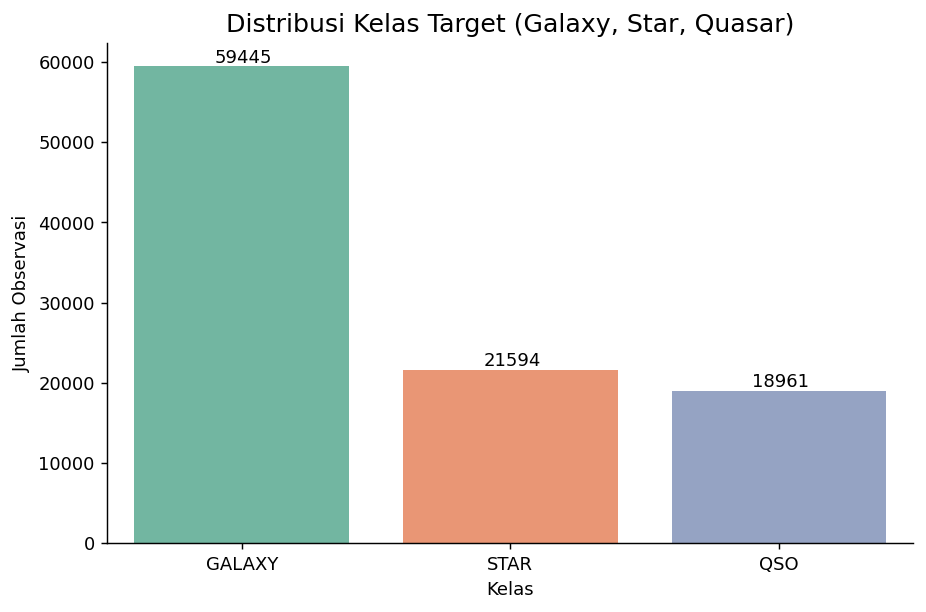

In [58]:
# Barchart distribusi kelas target
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='class', 
              order=df['class'].value_counts().index, 
              palette='Set2')

plt.title('Distribusi Kelas Target (Galaxy, Star, Quasar)', fontsize=14)
plt.ylabel('Jumlah Observasi')
plt.xlabel('Kelas')

for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 500))

plt.show()

Dari bar chart tersebut terlihat ada imbalanced data karena jumlahnya cenderung banyak di Galaxy dibandingkan Star dan Quasar.

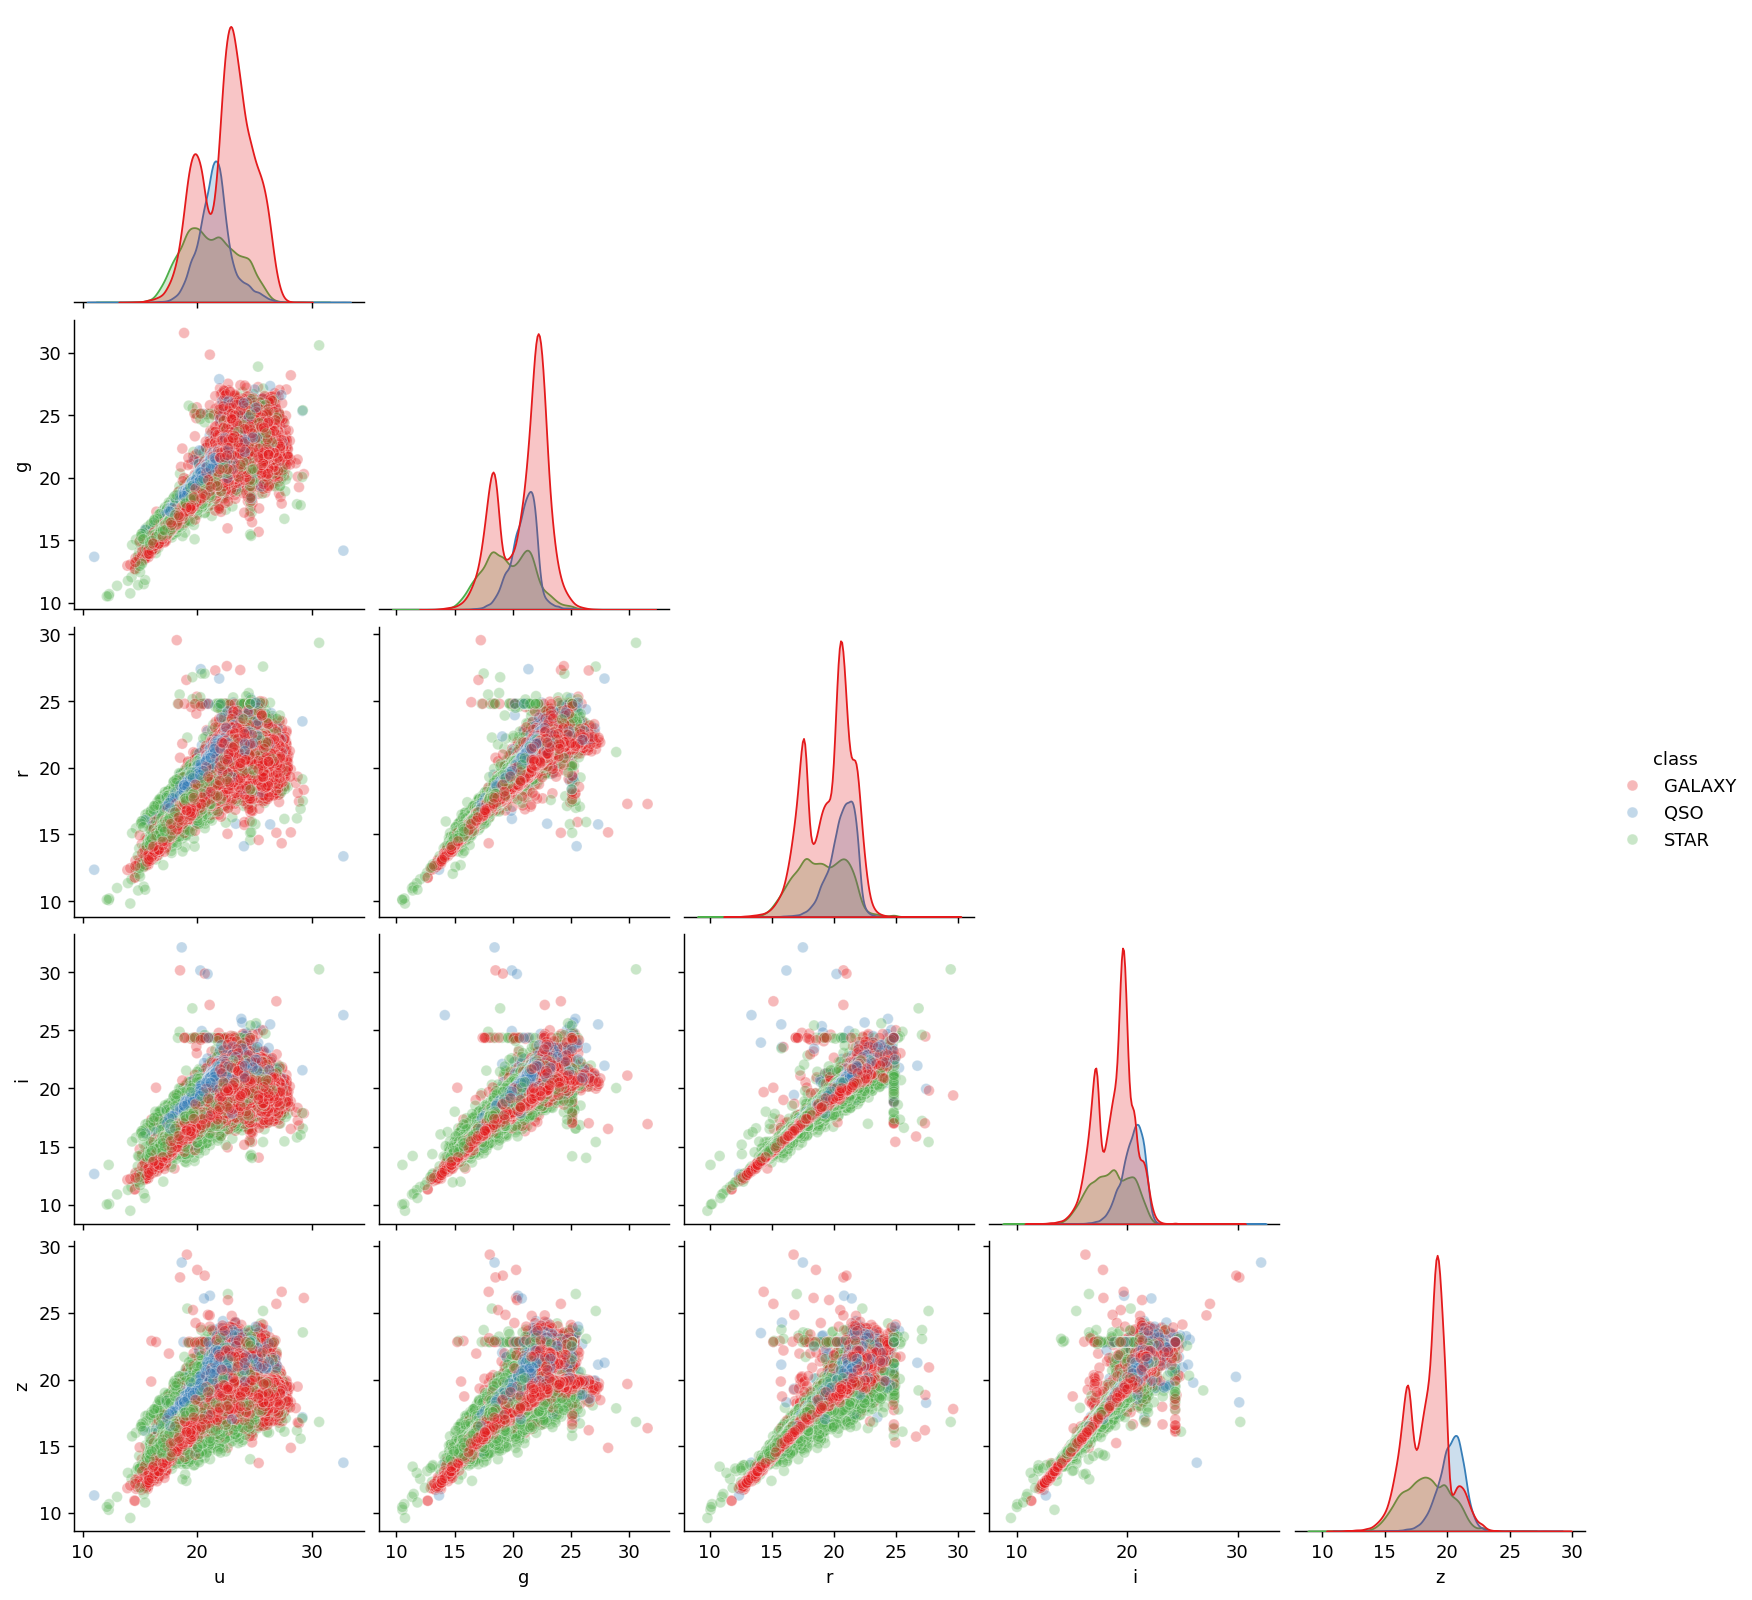

In [59]:
# Pairplot Distribusi Magnitudo Fotometrik (u, g, r, i, z) Berdasarkan Kelas Objek
sns.pairplot(df[['u', 'g', 'r', 'i', 'z', 'class']], 
              hue='class', diag_kind='kde', corner=True, palette='Set1', plot_kws={'alpha': 0.3})
plt.show()

Dari pairplot tersebut terlihat bahwa kelas target tersebar tidak merata/berkumpul di suatu area pada seluruh variabel numerik. Diperlukan model tree-based atau feature engineering tingkat lanjut.

Namun ditemukan adanya pola yang aneh di sekitar angka 25, yakni membentuk suatu garis lurus. Dalam konteks astronomi ini bisa diakibatkan oleh:
    
    a. Saturation / Detection Limit
Instrumen teleskop memiliki:
batas sensitivitas,
noise floor,
clipping magnitudo.
Objek sangat terang atau sangat redup bisa “menumpuk” pada rentang tertentu.

    b. Quantization Magnitude
Data SDSS sering mengalami:
pembulatan nilai magnitudo,
discretization kecil akibat preprocessing pipeline.

    c. Selection Bias
SDSS menggunakan:
target selection tertentu,
magnitude cut-off.

Akibatnya distribusi objek tidak benar-benar natural.

In [ ]:
# Cek data yang terlalu sering muncul
for col in ['u','g','r','i','z']:
    print(df[col].value_counts().head(10))

u
24.63465    77
24.63466    64
24.63467    44
24.63464    23
24.63468    20
24.63463     5
20.26008     4
24.63462     4
19.95185     4
23.43341     4
Name: count, dtype: int64
g
25.11439    9
25.11438    9
25.11437    8
21.94795    4
20.98246    4
22.37168    4
21.40104    4
22.56372    4
21.81087    4
21.65138    4
Name: count, dtype: int64
r
24.80203    21
24.80202    15
24.80204     7
20.72245     6
20.76527     5
20.74657     5
20.51180     4
20.75580     4
20.24885     4
20.64847     4
Name: count, dtype: int64
i
24.36181    6
24.36180    6
18.63308    5
19.70201    4
19.67620    4
18.63051    4
20.23400    4
19.83250    4
19.60160    4
19.62323    4
Name: count, dtype: int64
z
22.82690    58
22.82691    25
22.82689    25
22.82692    12
19.26912     4
20.68561     4
18.89468     4
19.50887     4
19.88720     4
17.87164     4
Name: count, dtype: int64


Karena dapat dilihat ada beberapa nilai yang muncul sangat sering, maka penanganan yang tepat adalah menambahkan flag agar model kedepannya tahu bahwa data tersebut mencapai batas maksimum pengukuran (sangat redup).

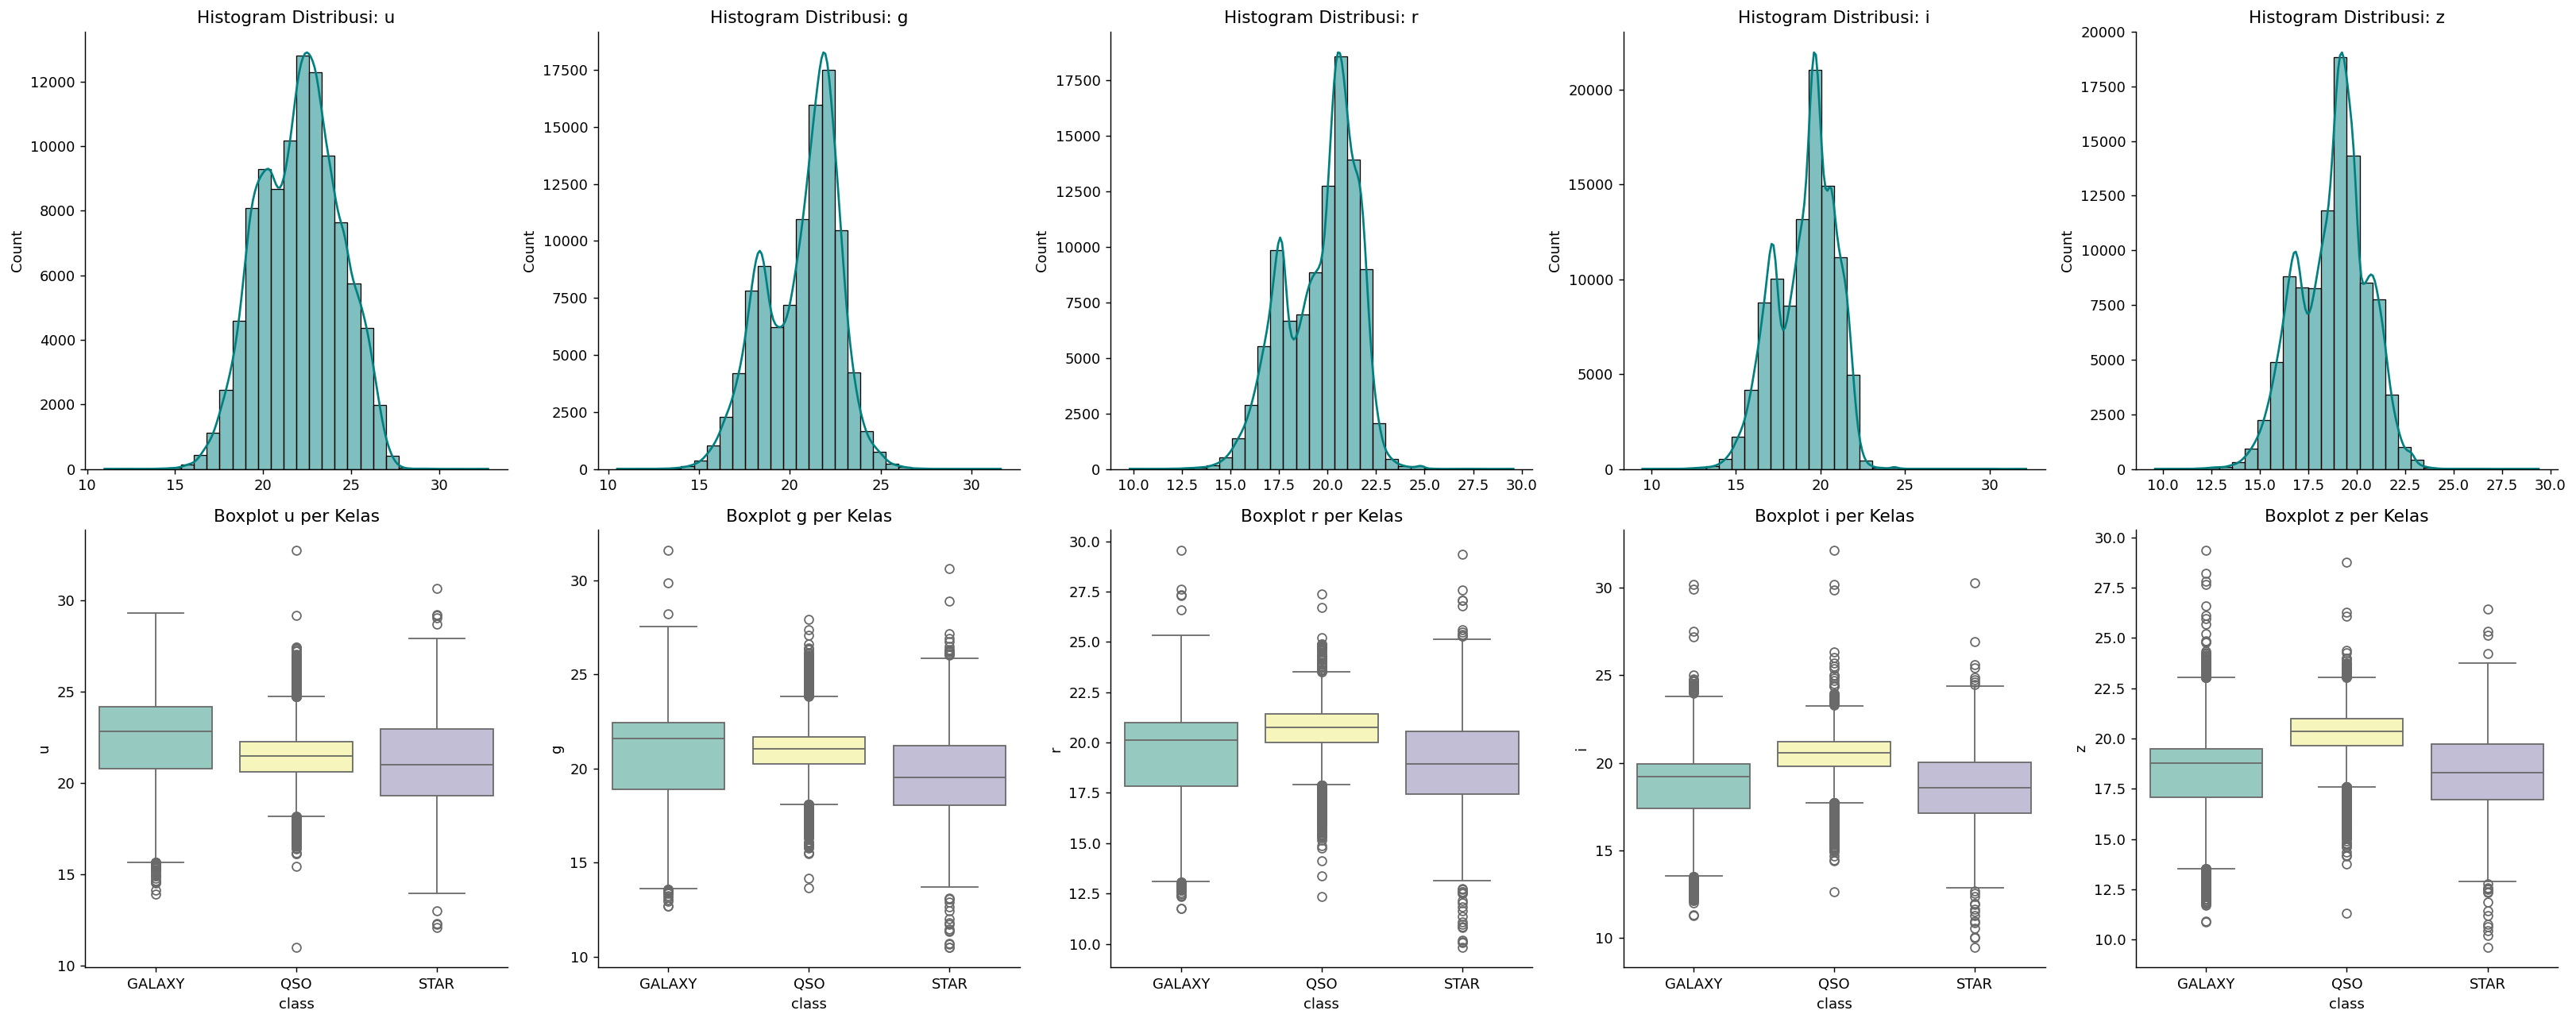

In [45]:
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
mags = ['u', 'g', 'r', 'i', 'z']

for i, col in enumerate(mags):
    # Baris 0: Histogram (Distribusi keseluruhan)
    sns.histplot(data=df, x=col, kde=True, ax=axes[0, i], color='teal', bins=30)
    axes[0, i].set_title(f'Histogram Distribusi: {col}')
    axes[0, i].set_xlabel('')
    
    # Baris 1: Boxplot per Kelas (Mengecek Outlier dan Range per Kelas)
    sns.boxplot(data=df, y=col, x='class', ax=axes[1, i], palette='Set3')
    axes[1, i].set_title(f'Boxplot {col} per Kelas')

plt.tight_layout()
plt.show()

Dari visualisasi di atas, terlihat distribusinya bimodal atau terdapat 2 puncak. Selain itu, ada banyak outlier. Namun dalam konteks astronomi, titik-titik ekstrem tersebut bisa jadi adalah objek dengan luminositas sangat tinggi atau Bintang kerdil yang sangat redup. Adapun boxplot Quasar cenderung sedikit lebih sempit dan lebih padat dibandingkan yang lain, namun sebarannya (whiskers dan outliers) sangat panjang. Ini mencerminkan sifat astrofisika Quasar yang memiliki pancaran energi sangat ekstrem dan bervariasi.


#### 3. Feature Engineering

##### 1) Memberi Flag
Seperti yang telah ditelusuri di tahap EDA sebelumnya, terdapat anomali berupa nilai-nilai membentk garis vertikal. Penanganannya adalah melabeli flag agar model tahu bahwa nilai tersebut dekat dengan ambang teleskop.

In [98]:
# =====================================================================
# 1. FLAG NILAI MELEBIHI AMBANG BATAS
# =====================================================================
df['u_limit_flag'] = (df['u'] > 24.5).astype(int)
df['r_limit_flag'] = (df['r'] > 24.5).astype(int)

##### 2) Filter Warna Berurutan
Filter SDSS tersusun berurutan berdasarkan panjang gelombang:

u → g → r → i → z

dari:
ultraviolet, visible, near infrared

Masing-masing band menangkap bagian spektrum yang saling berdekatan.
Fitur tambahan diperlukan berupa:
- u-g → slope UV-visible
- g-r → slope visible-red
- r-i → slope red-NIR
- i-z → slope NIR-IR

In [ ]:
# =====================================================================
# 2. MENGEKSTRAK WARNA
# =====================================================================
df['u-g'] = df['u'] - df['g']
df['g-r'] = df['g'] - df['r']
df['r-i'] = df['r'] - df['i']
df['i-z'] = df['i'] - df['z']

In [71]:
# Verifikasi hasil perhitungan
print("Statistika Deskriptif Fitur Indeks Warna:")
print(df[['u-g', 'g-r', 'r-i', 'i-z']].describe())

Statistika Deskriptif Fitur Indeks Warna:
                u-g           g-r           r-i           i-z
count  99999.000000  99999.000000  99999.000000  99999.000000
mean       1.449096      0.985806      0.560912      0.315877
std        1.179332      0.734675      0.501518      0.420396
min      -12.748140    -12.318610    -14.649070    -13.162490
25%        0.631245      0.379810      0.216320      0.134500
50%        1.321710      0.931460      0.479800      0.338030
75%        2.044565      1.577985      0.892205      0.474080
max       18.624950     14.315170     12.205800     13.427100


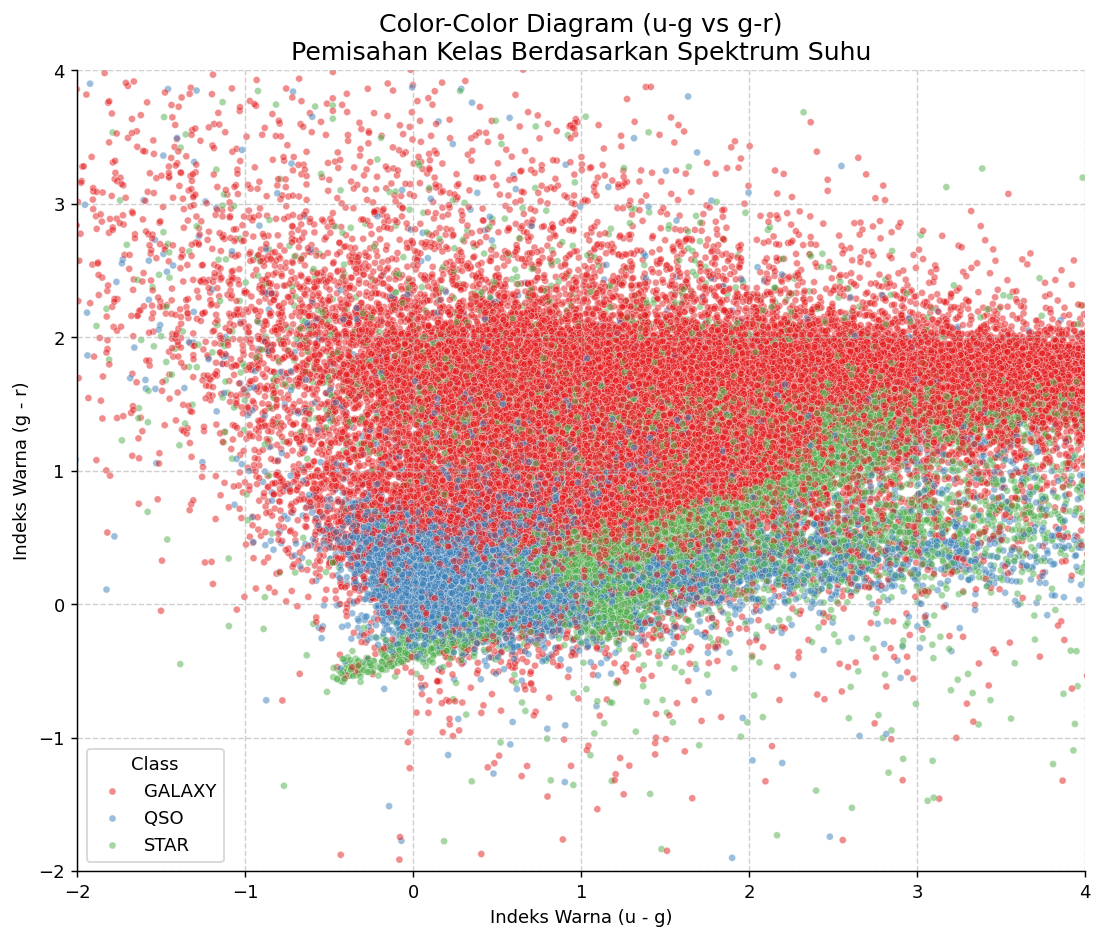

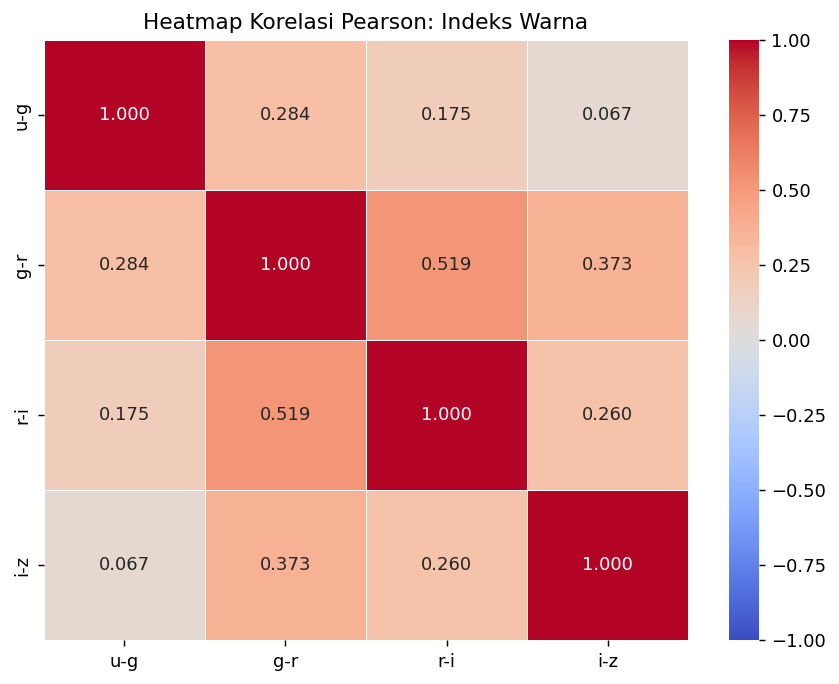

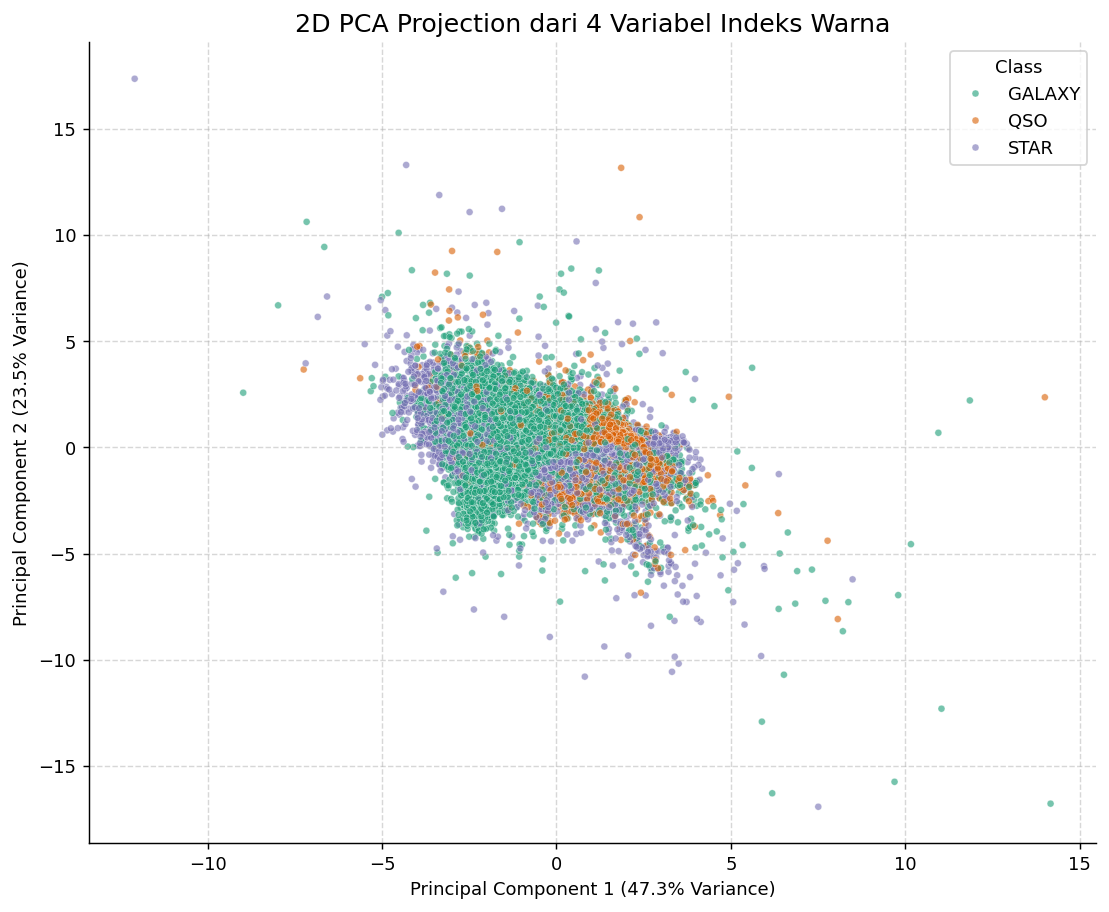

In [73]:
# ==========================================
# VISUALISASI 1: Color-Color Diagram
# ==========================================
plt.figure(figsize=(10, 8))
# Memplot u-g vs g-r
sns.scatterplot(data=df, x='u-g', y='g-r', hue='class', 
                palette='Set1', s=15, alpha=0.5)

plt.title('Color-Color Diagram (u-g vs g-r)\nPemisahan Kelas Berdasarkan Spektrum Suhu', fontsize=14)
plt.xlabel('Indeks Warna (u - g)')
plt.ylabel('Indeks Warna (g - r)')

# Memotong sumbu untuk mengabaikan sisa outlier ekstrem agar pola utama terlihat
plt.xlim(-2, 4)
plt.ylim(-2, 4)
plt.legend(title='Class')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# ==========================================
# VISUALISASI 2: Heatmap Korelasi (Evaluasi Multikolinearitas)
# ==========================================
plt.figure(figsize=(8, 6))
# Matriks korelasi khusus untuk 4 fitur indeks warna baru
corr_matrix_new = df[['u-g', 'g-r', 'r-i', 'i-z']].corr()

sns.heatmap(corr_matrix_new, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            fmt=".3f", linewidths=0.5)

plt.title('Heatmap Korelasi Pearson: Indeks Warna', fontsize=12)
plt.show()

# ==========================================
# VISUALISASI 3: Analisis Komponen Utama (PCA)
# ==========================================
features_pca = ['u-g', 'g-r', 'r-i', 'i-z']
x = df[features_pca].values

# Standarisasi wajib dilakukan sebelum PCA agar skala antar variabel seragam
x_scaled = StandardScaler().fit_transform(x)

# Proyeksi ke 2 Komponen Utama
pca = PCA(n_components=2)
principal_components = pca.fit_transform(x_scaled)
df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
# Pastikan indeks tidak bergeser saat menggabungkan kembali dengan kolom target
df_pca['class'] = df['class'].values 

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='class', 
                palette='Dark2', s=15, alpha=0.6)

plt.title('2D PCA Projection dari 4 Variabel Indeks Warna', fontsize=14)
# Menampilkan seberapa besar variansi data asli yang bisa dijelaskan oleh tiap PC
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.legend(title='Class')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Berdasarkan hasil proyeksi PCA 2D yang menunjukkan tumpang tindih kelas secara masif dan batas keputusan yang non-linear, maka pemodelan klasifikasi ini tidak bisa diselesaikan dengan algoritma linear sederhana seperti Regresi Logistik. Oleh karena itu, penelitian ini wajib menggunakan algoritma non-linear yang kompleks seperti Random Forest, XGBoost, atau Neural Networks.

##### 3) PCA Components
Indeks warna (u-g, g-r, dll.) masih memiliki korelasi linear terselubung karena mereka berbagi variabel yang sama (misalnya, g ada di u-g dan g-r). PCA akan mengekstrak variansi terbesar dari kombinasi warna ini dan mentransformasikannya menjadi sumbu baru yang ortogonal (sama sekali tidak berkorelasi).

In [75]:
# =====================================================================
# 3. MENAMBAH FITUR PCA COMPONENTS
# =====================================================================
features_color = ['u-g', 'g-r', 'r-i', 'i-z']
X_color = df[features_color].values

# Standarisasi wajib sebelum PCA
scaler = StandardScaler()
X_color_scaled = scaler.fit_transform(X_color)

# Ekstrak 3 Komponen Utama (Menangkap ~90%+ variansi)
pca = PCA(n_components=3)
pca_features = pca.fit_transform(X_color_scaled)

# Masukkan ke dalam dataframe utama
df['PC1'] = pca_features[:, 0]
df['PC2'] = pca_features[:, 1]
df['PC3'] = pca_features[:, 2]

##### 4) Distance From Stellar Locus

Di alam semesta, bintang-bintang (STAR) memiliki karakteristik radiasi benda hitam yang teratur. Ketika diplot dalam color-color diagram (misalnya u-g vs g-r), bintang tidak tersebar acak, melainkan berkumpul membentuk jalur melengkung yang sangat spesifik dan sempit yang disebut Stellar Locus. Sementara itu, Quasar (QSO) dan Galaksi (GALAXY) tersebar acak jauh di luar jalur tersebut.

In [ ]:
# =====================================================================
# 4. MENAMBAH FITUR DISTANCE FROM STELLAR LOCUS
# =====================================================================
# Langkah A: Pisahkan data yang khusus bertipe 'STAR' untuk mendesain garis Locus
df_stars = df[df['class'] == 'STAR']

# Kita petakan Locus pada diagram paling populer: u-g (Sumbu X) vs g-r (Sumbu Y)
X_star_ug = df_stars['u-g']
y_star_gr = df_stars['g-r']

# Langkah B: Buat model garis Locus menggunakan Regresi Polinomial Derajat 3
poly_coeffs = np.polyfit(X_star_ug, y_star_gr, deg=3)
locus_function = np.poly1d(poly_coeffs)

# Langkah C: Hitung jarak absolut (residual) dari fungsi Locus untuk SEMUA data
# Jarak = | y_aktual - y_prediksi_locus |
df['dist_locus'] = np.abs(df['g-r'] - locus_function(df['u-g']))

In [78]:
# =====================================================================
# VERIFIKASI SEBARAN FITUR BARU
# =====================================================================
print("=== Verifikasi Fitur Hasil Engineering ===")
print(df[['PC1', 'PC2', 'PC3', 'dist_locus']].head())

print("\n=== Rata-rata Jarak ke Stellar Locus per Kelas ===")
# Bintang (STAR) harusnya memiliki rata-rata jarak yang paling kecil/dekat ke Locus
print(df.groupby('class')['dist_locus'].mean())

=== Verifikasi Fitur Hasil Engineering ===
        PC1       PC2       PC3  dist_locus
0 -1.593419  0.075713 -0.851803    1.235004
1  0.337458 -1.195043 -1.993974    0.484991
2 -2.090204 -0.593385 -0.565674    1.132083
3 -1.700169  3.495430 -0.344248    1.283115
4 -0.276968 -0.149234  0.348347    0.374018

=== Rata-rata Jarak ke Stellar Locus per Kelas ===
class
GALAXY    0.656184
QSO       0.356043
STAR      0.369523
Name: dist_locus, dtype: float64


#### 4. Modelling & Evaluation

##### Persiapan

Dalam modelling ini hanya akan digunakan variabel x berupa:                                                             
'r', 'u-g', 'g-r', 'r-i', 'i-z', 'PC1', 'PC2', 'PC3', 'dist_locus', 'u_limit_flag',                         'r_limit_flag'                                                                                                                                   
Sedangkan untuk 'u', 'g', 'i', 'z' tidak digunakan karena ia akan memicu multikolinearitas berbahaya.

In [99]:
# 1. Definisikan Matriks Fitur (X) dan Target (y)
# Gunakan fitur murni hasil rekayasa kita
fitur_final = ['r', 'u-g', 'g-r', 'r-i', 'i-z', 'PC1', 'PC2', 'PC3', 'dist_locus', 'u_limit_flag', 'r_limit_flag']
X = df[fitur_final]
y_raw = df['class']

# 2. Label Encoding WAJIB untuk XGBoost
# Mengubah 'GALAXY', 'QSO', 'STAR' menjadi angka 0, 1, 2
encoder = LabelEncoder()
y = encoder.fit_transform(y_raw)
kelas_target = encoder.classes_
print(f"Mapping Kelas Target: {dict(enumerate(kelas_target))}\n")

# 3. Train-Test Split (80% Pelatihan, 20% Pengujian)
# Parameter stratify=y wajib agar proporsi kelas di set pelatihan dan pengujian sama
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Standarisasi Fitur (Sangat penting untuk Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Pastikan X_test hanya di-transform, BUKAN di fit_transform agar tidak ada data leakage!
X_test_scaled = scaler.transform(X_test)

Mapping Kelas Target: {0: 'GALAXY', 1: 'QSO', 2: 'STAR'}



Permodelan dengan 3 Model : Logistic Regression (baseline), XGBoost, Random Forest

Melatih Model: 1. Logistic Regression (Baseline)...
Accuracy : 0.7587
Macro F1 : 0.6706

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.80      0.91      0.85     11889
         QSO       0.68      0.79      0.74      3792
        STAR       0.67      0.31      0.43      4319

    accuracy                           0.76     20000
   macro avg       0.72      0.67      0.67     20000
weighted avg       0.75      0.76      0.74     20000


Melatih Model: 2. Random Forest...
Accuracy : 0.8828
Macro F1 : 0.8492

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.91      0.95      0.93     11889
         QSO       0.82      0.80      0.81      3792
        STAR       0.85      0.77      0.81      4319

    accuracy                           0.88     20000
   macro avg       0.86      0.84      0.85     20000
weighted avg       0.88      0.88      0.88     20000


Melatih Model: 3. XGBoost Cla

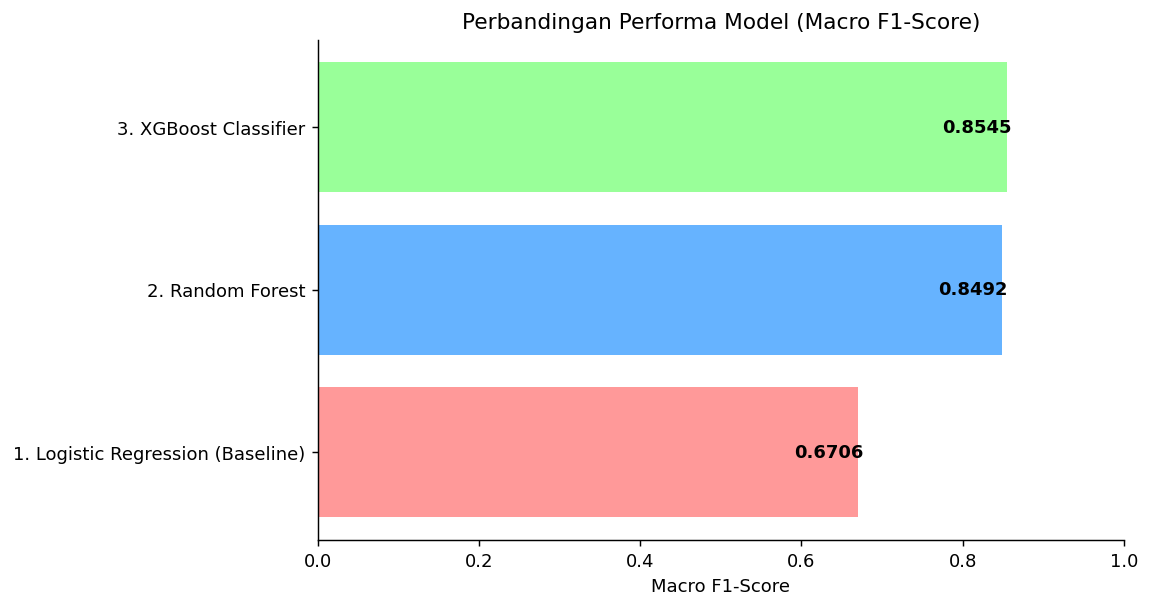

In [100]:
# 1. Inisialisasi Ketiga Model
models = {
    "1. Logistic Regression (Baseline)": LogisticRegression(
        max_iter=2000, 
        multi_class='multinomial', 
        random_state=42
    ),
    "2. Random Forest": RandomForestClassifier(
        n_estimators=100, 
        class_weight='balanced', 
        random_state=42,
        n_jobs=-1 # Gunakan seluruh core CPU agar cepat
    ),
    "3. XGBoost Classifier": XGBClassifier(
        objective='multi:softmax', 
        num_class=3, 
        random_state=42,
        eval_metric='mlogloss',
        n_jobs=-1
    )
}

# 2. Dictionary untuk menyimpan skor agar mudah dibandingkan nanti
f1_scores = {}

# 3. Looping Pelatihan, Prediksi, dan Evaluasi
for nama_model, model in models.items():
    print("="*60)
    print(f"Melatih Model: {nama_model}...")
    
    # Pelatihan Model
    model.fit(X_train_scaled, y_train)
    
    # Prediksi
    y_pred = model.predict(X_test_scaled)
    
    # Menghitung Metrik
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    f1_scores[nama_model] = f1
    
    # Cetak Hasil
    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {f1:.4f}")
    print("\nClassification Report:")
    # Menampilkan report dengan nama kelas asli, bukan angka 0,1,2
    print(classification_report(y_test, y_pred, target_names=kelas_target))
    print("="*60 + "\n")

# 4. Evaluasi Visual Akhir: Perbandingan F1-Score
plt.figure(figsize=(8, 5))
bars = plt.barh(list(f1_scores.keys()), list(f1_scores.values()), color=['#ff9999', '#66b3ff', '#99ff99'])
plt.xlabel('Macro F1-Score')
plt.title('Perbandingan Performa Model (Macro F1-Score)')
plt.xlim(0, 1)

# Menambahkan anotasi angka pada bar
for bar in bars:
    plt.text(bar.get_width() - 0.08, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.4f}', va='center', color='black', fontweight='bold')

plt.show()

Melihat Feature Importance

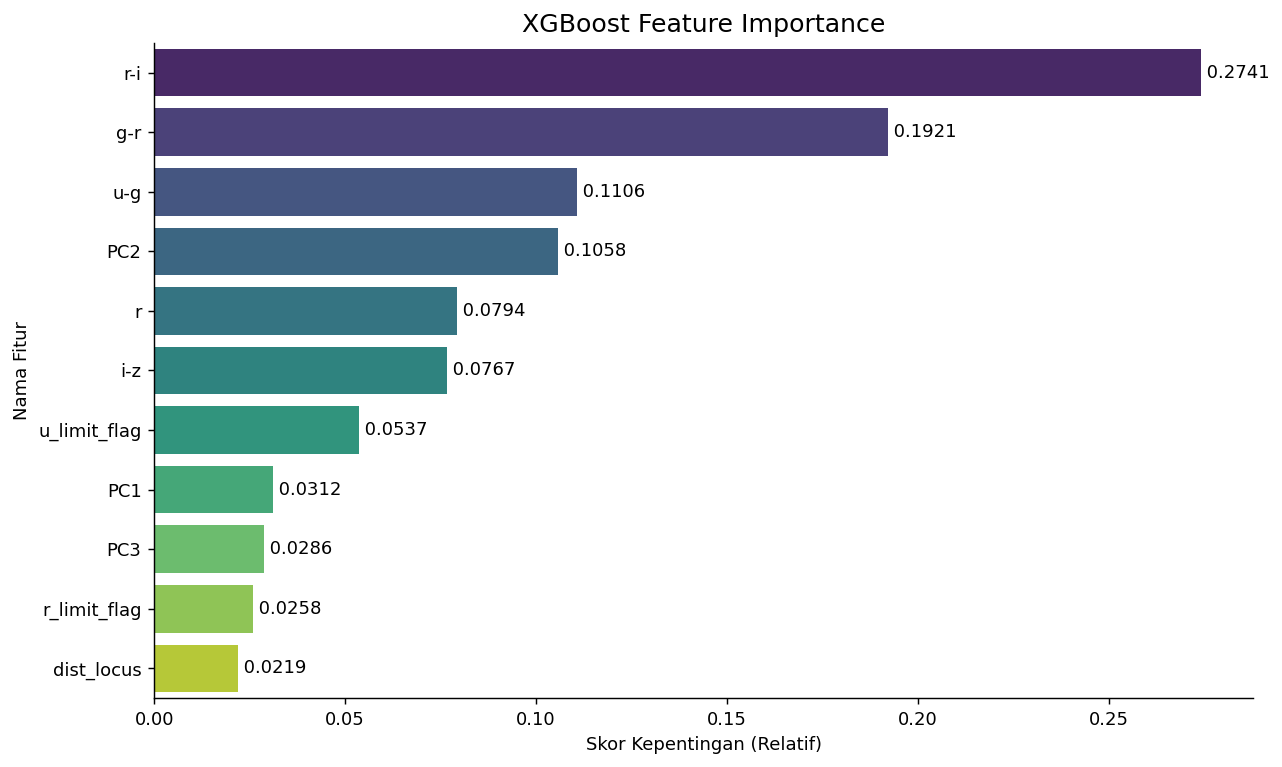

In [101]:
# 1. Ekstrak model XGBoost dari dictionary yang sudah kita buat sebelumnya
xgb_model = models["3. XGBoost Classifier"]

# 2. Ambil nilai feature importances bawaan model
importances = xgb_model.feature_importances_

# 3. Buat DataFrame agar rapi dan urutkan dari yang paling penting
df_importance = pd.DataFrame({
    'Fitur': fitur_final, # Pastikan variabel fitur_final sama dengan saat training
    'Tingkat Kepentingan (Gain)': importances
})
df_importance = df_importance.sort_values(by='Tingkat Kepentingan (Gain)', ascending=False)

# 4. Visualisasi dengan Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Tingkat Kepentingan (Gain)', y='Fitur', data=df_importance, palette='viridis')

plt.title('XGBoost Feature Importance', fontsize=14)
plt.xlabel('Skor Kepentingan (Relatif)')
plt.ylabel('Nama Fitur')

# Tambahkan anotasi angka
for index, value in enumerate(df_importance['Tingkat Kepentingan (Gain)']):
    plt.text(value, index, f' {value:.4f}', va='center')

plt.tight_layout()
plt.show()

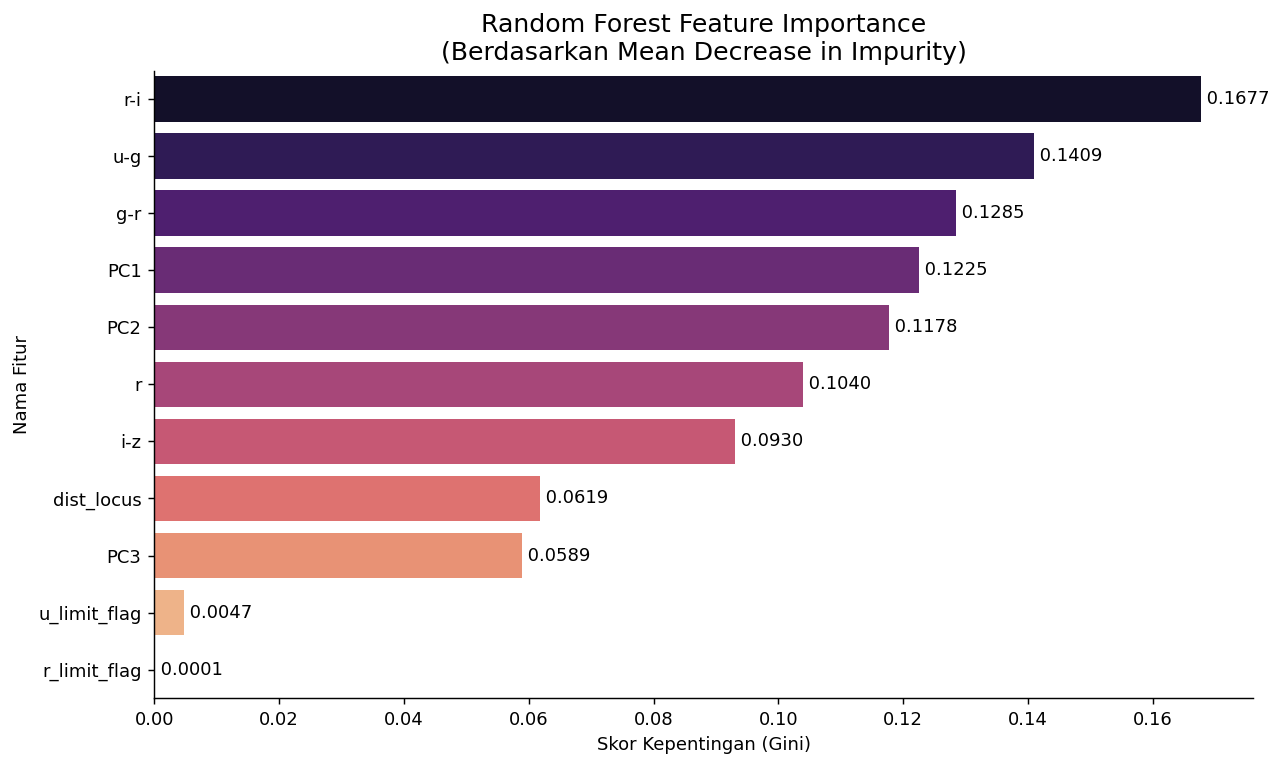

In [ ]:
# 1. Ekstrak model Random Forest dari dictionary
rf_model = models["2. Random Forest"]

# 2. Ambil nilai feature importances bawaan model RF (berbasis Gini Impurity)
rf_importances = rf_model.feature_importances_

# 3. Buat DataFrame dan urutkan
df_rf_importance = pd.DataFrame({
    'Fitur': fitur_final, # Pastikan ini matriks yang sudah RAMPING!
    'Tingkat Kepentingan (Gini)': rf_importances
})
df_rf_importance = df_rf_importance.sort_values(by='Tingkat Kepentingan (Gini)', ascending=False)

# 4. Visualisasi dengan Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Tingkat Kepentingan (Gini)', y='Fitur', data=df_rf_importance, palette='magma')

plt.title('Random Forest Feature Importance\n(Berdasarkan Mean Decrease in Impurity)', fontsize=14)
plt.xlabel('Skor Kepentingan (Gini)')
plt.ylabel('Nama Fitur')

# Tambahkan anotasi angka
for index, value in enumerate(df_rf_importance['Tingkat Kepentingan (Gini)']):
    plt.text(value, index, f' {value:.4f}', va='center')

plt.tight_layout()
plt.show()

Menyimpan Model

In [ ]:
# 1. Simpan Model Utama
joblib.dump(xgb_model, 'xgboost_stellar_model.pkl')

# 2. Simpan Objek Preprocessing (Sangat Fatal Jika Terlupakan!)
# Asumsi: Kamu sudah mendefinisikan 'scaler', 'pca', dan 'encoder' di notebook
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca, 'pca.pkl')
joblib.dump(encoder, 'label_encoder.pkl')

print("Artefak model dan preprocessor berhasil diekspor!")

Artefak model dan preprocessor berhasil diekspor!
